#FUENTE:
###[Conexión Dalle a Colab](https://colab.research.google.com/github/edgeimpulse/notebooks/blob/main/notebooks/generate-dall-e-image-dataset.ipynb#scrollTo=TXyrgOo41vJS)
###[Migración](https://github.com/openai/openai-python/discussions/742)

In [2]:
!pip list | grep openai

openai                                1.97.1


In [3]:
# Install OpenAI package
# This is required to interact with OpenAI's API
#!pip install openai

# Import necessary libraries
from openai import OpenAI
import requests
import os
import time


In [4]:
import json

In [7]:
# Open AI API-key
from google.colab import files
from IPython.display import clear_output

files.upload() # subir archivo con apikey de openai propio
clear_output() # no muestra contenido del apikey

In [8]:
!ls

anahi_openai_key.txt  idsa_openai_key.txt  sample_data


In [9]:
def get_api_key():
    with open('idsa_openai_key.txt', 'r') as fp: #acá reemplazar x el nombre de tu archivo
        key = fp.read()
    return key

# Enter your OpenAI API key here
openai_api_key = get_api_key()

In [10]:
# DEFINE some functions...

def safe_create_directory(path):
    """Safely create a directory. If the directory already exists, do nothing."""
    os.makedirs(path, exist_ok=True)

# Function to enhance prompt using GPT-3.5 with the chat completions endpoint
def enhance_prompt(prompt, openai_api_key):
    """Enhances the given image prompt using GPT-3.5."""
    url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-3.5-turbo",
        "messages": [{
            "role": "user",
            "content": f"Improve this image prompt: {prompt}."
        }]
    }

    response = requests.post(url, headers=headers, data=json.dumps(data))
    if response.status_code == 200:
        response_json = response.json()
        latest_response = response_json.get('choices', [])[0].get('message', {}).get('content', '')
        return latest_response.strip()
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return prompt  # Return the original prompt in case of error to avoid breaking the loop

# Initialize a global counter for image filenames
image_counter = 1

def generate_and_save_images(prompt, n=1):
    """Generates and saves images based on the given prompt."""
    global image_counter  # Reference the global counter

    client = OpenAI(api_key=openai_api_key)
    response = client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size="1024x1792",
        quality="standard",
        n=n,
    )

    # Path to save images in root /content/Dalle3/
    drive_folder = "/content/Dalle3/"
    safe_create_directory(drive_folder)

    for idx, image in enumerate(response.data):
        image_url = image.url
        image_response = requests.get(image_url)

        # Use the global counter in the filename to ensure a unique, sequential name
        filename = os.path.join(drive_folder, f"image{image_counter}.png")
        with open(filename, 'wb') as file:
            file.write(image_response.content)
        print(f"Image saved as {filename}")

        # Increase the counter for the next image
        image_counter += 1


In [11]:
# Starting prompt
start_prompt = ''  #"Generate an image of white tiger, with a crown and a blue suit from italian designer"

# Loop to continuously enhance prompt, generate and save images
for i in range(3):
    enhanced_prompt = enhance_prompt(start_prompt, openai_api_key)
    print(f"Generating images for: {enhanced_prompt}")
    generate_and_save_images(enhanced_prompt, n=1)  # Adjusted API'

Generating images for: Create an image of a majestic white tiger wearing a luxurious crown on its head and dressed in a sleek blue suit by a renowned Italian designer. The tiger's vibrant blue suit perfectly complements its striking white fur, creating a regal and elegant aesthetic. The powerful yet graceful animal exudes confidence and sophistication as it prowls through its royal surroundings.
Image saved as /content/Dalle3/image1.png
Generating images for: Create an image of a majestic white tiger adorned with a sparkling crown atop its head and dressed in a sleek, tailored blue suit from a top Italian designer. The tiger's regal pose and luxurious attire make it look like the ultimate fashion icon of the animal kingdom.
Image saved as /content/Dalle3/image2.png
Generating images for: Create an image of a majestic white tiger, adorned with a regal crown on its head and dressed in a luxurious blue suit crafted by a renowned Italian designer. The tiger poses confidently, showcasing it

In [15]:
!ls /content/Dalle3/


image1.png  image2.png	image3.png


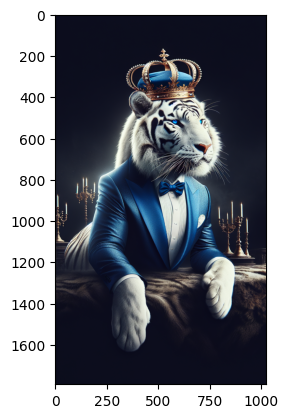

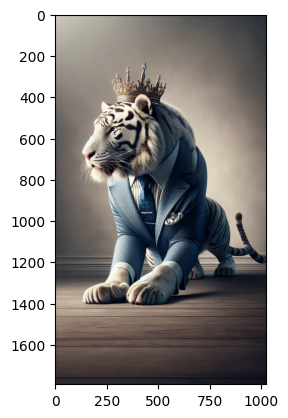

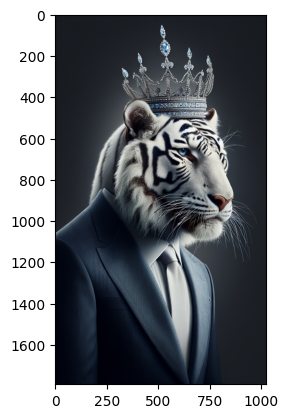

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as img

path_dalle='/content/Dalle3/'
imagenes=os.listdir(path_dalle)
#print(imagenes)
# Travers all the branch of a specified path
for imagen in imagenes:
    image = img.imread(path_dalle + imagen)
    plt.imshow(image)
    plt.show()


In [ ]:
!ls Dalle3

image1.png  image2.png	image3.png
